# Social Media Network Analytics

## From Data Collection to Network Visualization and Insights

This  project analyzes a Twitter social network using Python, NetworkX, Gephi to identify influential users, highly connected nodes, communities, and important structural characteristics of the network.

In [1]:
import pandas as pd
print ("pandas imported successfully!")

pandas imported successfully!


In [14]:
file_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\data\raw\twitter_combined.txt"

df = pd.read_csv(
    file_path,
    sep=" ",
    header=None,
    names=["source", "target"]
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [13]:
import os

folder = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\data\raw"

print("Folder exists:", os.path.exists(folder))
print("\nFiles inside raw folder:")

for file in os.listdir(folder):
    print(repr(file))

Folder exists: True

Files inside raw folder:
'twitter_combined.txt'


In [ ]:
#see first 5 rows
df.head()

,source,target
0,214328887,34428380
1,17116707,28465635
2,380580781,18996905
3,221036078,153460275
4,107830991,17868918


In [16]:
#check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2420766
Number of columns: 2


In [17]:
#check col names
print(df.columns)

Index(['source', 'target'], dtype='str')


In [18]:
#check data types
print(df.dtypes)

source    int64
target    int64
dtype: object


In [19]:
#check missing values
print(df.isnull().sum())

source    0
target    0
dtype: int64


In [20]:
#check duplicates connections
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 652617


In [21]:
#count unique users
unique_users = pd.unique(
    pd.concat([df["source"], df["target"]])
)

print("Number of unique users:", len(unique_users))

Number of unique users: 81306


In [ ]:
#check self-connections
self_loops = (df["source"] == df["target"]).sum()

print("Number of self-loops:", self_loops)

Number of self-loops: 22


In [23]:
#remove duplicates
df_clean = df.drop_duplicates().copy()

print("Original number of connections:", len(df))
print("Connections after removing duplicates:", len(df_clean))

Original number of connections: 2420766
Connections after removing duplicates: 1768149


In [24]:
#remove self-loops
df_clean = df_clean[
    df_clean["source"] != df_clean["target"]
].copy()

print("Connections after removing self-loops:", len(df_clean))

Connections after removing self-loops: 1768135


In [25]:
#check cleaned dataset
print("----- CLEANED DATASET -----")
print("Connections:", len(df_clean))
print("Users:", len(
    pd.unique(
        pd.concat([df_clean["source"], df_clean["target"]])
    )
))
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate connections:", df_clean.duplicated().sum())

----- CLEANED DATASET -----
Connections: 1768135
Users: 81306
Missing values: 0
Duplicate connections: 0


In [26]:
#save cleaned dataset
processed_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\data\processed\twitter_network_clean.csv"

df_clean.to_csv(processed_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [27]:
import networkx as nx

print("NetworkX version:", nx.__version__)

NetworkX version: 3.6.1


In [28]:
#create graph
G = nx.DiGraph()

print("Directed graph created successfully!")

Directed graph created successfully!


In [29]:
#add connections
G.add_edges_from(
    df_clean[["source", "target"]].itertuples(
        index=False,
        name=None
    )
)

print("Edges added successfully!")

Edges added successfully!


In [30]:
#check network
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 81306
Number of edges: 1768135


In [31]:
#verify network
print("Pandas connections:", len(df_clean))
print("NetworkX edges:", G.number_of_edges())

if len(df_clean) == G.number_of_edges():
    print("✓ Network successfully created!")
else:
    print("⚠ Edge count mismatch")

Pandas connections: 1768135
NetworkX edges: 1768135
✓ Network successfully created!


In [ ]:
#nodes
print("First 10 nodes:")

for node in list(G.nodes())[:10]:
    print(node)

First 10 nodes:
214328887
34428380
17116707
28465635
380580781
18996905
221036078
153460275
107830991
17868918


In [33]:
#connections
print("First 10 edges:")

for edge in list(G.edges())[:10]:
    print(edge)

First 10 edges:
(214328887, 34428380)
(214328887, 56860418)
(214328887, 157829215)
(214328887, 158419434)
(214328887, 14925700)
(214328887, 380580781)
(214328887, 155661154)
(214328887, 123371682)
(214328887, 86221475)
(214328887, 74107696)


In [34]:
#check whether graph is directed
print("Is the graph directed?", nx.is_directed(G))

Is the graph directed? True


In [35]:
#calculate network density
density = nx.density(G)

print("Network density:", density)

Network density: 0.0002674703039451279


In [36]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("In-degree calculated.")
print("Out-degree calculated.")

In-degree calculated.
Out-degree calculated.


In [37]:
#top 10 users by in-degree
top_in_degree = sorted(
    in_degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by in-degree:")

for user, degree in top_in_degree:
    print(user, degree)

Top 10 users by in-degree:
115485051 3383
40981798 3216
43003845 2735
813286 2647
22462180 2471
34428380 2462
15913 2133
7861312 2074
3359851 1905
11348282 1707


In [38]:
#top 10 users by out-degree
top_out_degree = sorted(
    out_degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by out-degree:")

for user, degree in top_out_degree:
    print(user, degree)

Top 10 users by out-degree:
59804598 1205
3359851 1158
813286 1111
5442012 1069
18581803 930
15846407 724
18776017 719
208132323 713
22679419 705
17093617 687


In [39]:
#calculate average degree
average_in_degree = sum(in_degrees.values()) / G.number_of_nodes()
average_out_degree = sum(out_degrees.values()) / G.number_of_nodes()

print("Average in-degree:", average_in_degree)
print("Average out-degree:", average_out_degree)

Average in-degree: 21.746673062258626
Average out-degree: 21.746673062258626


In [40]:
#calculate pagerank
print("Calculating PageRank...")

pagerank = nx.pagerank(G)

print("PageRank calculation completed!")

Calculating PageRank...
PageRank calculation completed!


In [41]:
#top 10 pagerank users
top_pagerank = sorted(
    pagerank.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by PageRank:")

for rank, (user, score) in enumerate(top_pagerank, start=1):
    print(rank, user, score)

Top 10 users by PageRank:
1 115485051 0.00433068490273396
2 116485573 0.004133243078380141
3 813286 0.00233879616279636
4 40981798 0.001371800248158703
5 7861312 0.0012537746536003412
6 11348282 0.0012219159174073832
7 17093617 0.0010756498116578433
8 15439395 0.0010307241084208795
9 18396070 0.001028682434495453
10 14230524 0.0010139210183864687


In [42]:
#calc degree centrality
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

print("Degree centrality calculated!")


Degree centrality calculated!


In [ ]:
#top 10 users by in-degree centrality
top_in_centrality = sorted(
    in_degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by in-degree centrality:")

for rank, (user, score) in enumerate(top_in_centrality, start=1):
    print(rank, user, score)

Top 10 users by in-degree centrality:
1 115485051 0.041608757149006824
2 40981798 0.039554762929709116
3 43003845 0.03363876760346842
4 813286 0.03255642334419777
5 22462180 0.030391734825656477
6 34428380 0.030281040526412888
7 15913 0.026234548920730582
8 7861312 0.025508886292355943
9 3359851 0.023430293339892994
10 11348282 0.020995018756534038


In [44]:
#top 10 users by out-degree centrality
top_out_centrality = sorted(
    out_degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by out-degree centrality:")

for rank, (user, score) in enumerate(top_out_centrality, start=1):
    print(rank, user, score)

Top 10 users by out-degree centrality:
1 59804598 0.014820736732058299
2 3359851 0.014242666502675111
3 813286 0.013664596273291925
4 5442012 0.013148022876821843
5 18581803 0.011438410921837524
6 15846407 0.008904741405817599
7 18776017 0.008843244572904495
8 208132323 0.008769448373408768
9 22679419 0.0086710534407478
10 17093617 0.008449664842260623


In [45]:
#approx betweenness where k is random sample nodes and seed ensures we get reproducible results
print("Calculating approximate betweenness centrality...")

betweenness = nx.betweenness_centrality(
    G,
    k=500,
    normalized=True,
    seed=42
)

print("Betweenness calculation completed!")

Calculating approximate betweenness centrality...
Betweenness calculation completed!


In [46]:
#find top 10 bridge users
top_betweenness = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by approximate betweenness centrality:")

for rank, (user, score) in enumerate(top_betweenness, start=1):
    print(rank, user, score)

Top 10 users by approximate betweenness centrality:
1 813286 0.16525738316030297
2 17093617 0.06368417800844357
3 15846407 0.05422265499812393
4 3359851 0.04812303252165054
5 15439395 0.030597375950651515
6 12611642 0.030566288357043666
7 59804598 0.026216443820589793
8 5442012 0.02276758554982205
9 22679419 0.020703333412265164
10 2367911 0.019908816279273545


In [ ]:
nx.closeness_centrality(G)

In [48]:
#create an unidirected version
G_undirected = G.to_undirected()

print("Undirected network created!")
print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())

Undirected network created!
Nodes: 81306
Edges: 1342296


In [49]:
#find connected components
components = list(nx.connected_components(G_undirected))

print("Number of connected components:", len(components))

Number of connected components: 1


In [50]:
#find the largest component
largest_component = max(components, key=len)

print("Largest component size:", len(largest_component))

Largest component size: 81306


In [51]:
#create the largest-component graph
G_largest = G_undirected.subgraph(largest_component).copy()

print("Largest component graph created!")
print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())

Largest component graph created!
Nodes: 81306
Edges: 1342296


In [53]:
print("Calculating approximate closeness centrality...")

sample_nodes = list(G_largest.nodes())

# Sample 1000 nodes
import random
random.seed(42)

sample_nodes = random.sample(
    sample_nodes,
    min(1000, len(sample_nodes))
)

closeness_approx = {}

for node in sample_nodes:
    distances = nx.single_source_shortest_path_length(
        G_largest,
        node
    )

    if len(distances) > 1:
        average_distance = sum(distances.values()) / len(distances)
        closeness_approx[node] = 1 / average_distance

print("Approximate closeness calculation completed!")

Calculating approximate closeness centrality...
Approximate closeness calculation completed!


In [54]:
top_closeness = sorted(
    closeness_approx.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 users by closeness centrality:")

for rank, (user, score) in enumerate(top_closeness, start=1):
    print(rank, user, score)

Top 10 users by closeness centrality:
1 73707412 0.3380664690253344
2 16726878 0.3365300640311919
3 49717874 0.33544431746450865
4 288452305 0.33526726622709896
5 37201612 0.3351760471932623
6 7852172 0.3345099975314737
7 166732373 0.33136080205404084
8 6206612 0.33112329258061624
9 9095652 0.3290515273663251
10 84043660 0.32761559383499544


In [55]:
#run louvain
import community.community_louvain as community_louvain

print("Detecting communities...")

partition = community_louvain.best_partition(
    G_undirected,
    random_state=42
)

print("Community detection completed!")

Detecting communities...
Community detection completed!


In [56]:
#count communities
num_communities = len(set(partition.values()))

print("Number of communities:", num_communities)

Number of communities: 73


In [57]:
#find community sizes
from collections import Counter

community_sizes = Counter(partition.values())

print("Community sizes:")

for community_id, size in community_sizes.most_common():
    print("Community", community_id, ":", size, "users")

Community sizes:
Community 6 : 9904 users
Community 11 : 8464 users
Community 8 : 6394 users
Community 0 : 6222 users
Community 52 : 4852 users
Community 62 : 4108 users
Community 23 : 3530 users
Community 33 : 2561 users
Community 7 : 2405 users
Community 5 : 1952 users
Community 30 : 1826 users
Community 1 : 1558 users
Community 14 : 1462 users
Community 9 : 1328 users
Community 15 : 1326 users
Community 31 : 1323 users
Community 69 : 1192 users
Community 29 : 1049 users
Community 56 : 998 users
Community 40 : 980 users
Community 54 : 965 users
Community 72 : 943 users
Community 19 : 772 users
Community 47 : 686 users
Community 34 : 636 users
Community 42 : 629 users
Community 37 : 624 users
Community 18 : 618 users
Community 35 : 593 users
Community 20 : 585 users
Community 27 : 544 users
Community 16 : 533 users
Community 48 : 515 users
Community 59 : 477 users
Community 41 : 472 users
Community 28 : 461 users
Community 21 : 442 users
Community 53 : 409 users
Community 38 : 395 use

In [58]:
#largest 10 communities
top_communities = community_sizes.most_common(10)

print("Top 10 largest communities:")

for rank, (community_id, size) in enumerate(top_communities, start=1):
    print(rank, "Community", community_id, ":", size, "users")

Top 10 largest communities:
1 Community 6 : 9904 users
2 Community 11 : 8464 users
3 Community 8 : 6394 users
4 Community 0 : 6222 users
5 Community 52 : 4852 users
6 Community 62 : 4108 users
7 Community 23 : 3530 users
8 Community 33 : 2561 users
9 Community 7 : 2405 users
10 Community 5 : 1952 users


In [59]:
#most imp user in each community
community_top_users = {}

for community_id in community_sizes:
    members = [
        user for user, comm in partition.items()
        if comm == community_id
    ]

    top_user = max(
        members,
        key=lambda user: pagerank.get(user, 0)
    )

    community_top_users[community_id] = (
        top_user,
        pagerank[top_user]
    )

In [60]:
#influential
print("Most influential user in the largest communities:")

for community_id, size in top_communities:
    user, score = community_top_users[community_id]

    print(
        "Community:", community_id,
        "| Size:", size,
        "| Top user:", user,
        "| PageRank:", score
    )

Most influential user in the largest communities:
Community: 6 | Size: 9904 | Top user: 115485051 | PageRank: 0.00433068490273396
Community: 11 | Size: 8464 | Top user: 15913 | PageRank: 0.0007287746078082508
Community: 8 | Size: 6394 | Top user: 972651 | PageRank: 0.0009201506391545177
Community: 0 | Size: 6222 | Top user: 40981798 | PageRank: 0.001371800248158703
Community: 52 | Size: 4852 | Top user: 63485337 | PageRank: 0.0007457151743489379
Community: 62 | Size: 4108 | Top user: 15853668 | PageRank: 0.0003913595622365411
Community: 23 | Size: 3530 | Top user: 11348282 | PageRank: 0.0012219159174073832
Community: 33 | Size: 2561 | Top user: 17093617 | PageRank: 0.0010756498116578433
Community: 7 | Size: 2405 | Top user: 36735522 | PageRank: 0.00022961917225166353
Community: 5 | Size: 1952 | Top user: 807095 | PageRank: 0.0005295711353179626


In [61]:
#avg clustering coeff
print("Calculating average clustering coefficient...")

average_clustering = nx.average_clustering(G_undirected)

print("Average clustering coefficient:", average_clustering)

Calculating average clustering coefficient...
Average clustering coefficient: 0.5653114686120824


In [62]:
#transitivity
transitivity = nx.transitivity(G_undirected)

print("Network transitivity:", transitivity)

Network transitivity: 0.17057220890342062


In [63]:
#network summary
print("\nNETWORK SUMMARY")

print("Number of users:", G.number_of_nodes())
print("Number of directed connections:", G.number_of_edges())
print("Network density:", nx.density(G))
print("Connected components:", nx.number_connected_components(G_undirected))
print("Average clustering:", average_clustering)
print("Network transitivity:", transitivity)
print("Number of communities:", num_communities)


NETWORK SUMMARY
Number of users: 81306
Number of directed connections: 1768135
Network density: 0.0002674703039451279
Connected components: 1
Average clustering: 0.5653114686120824
Network transitivity: 0.17057220890342062
Number of communities: 73


In [65]:
#master centrality table
results = pd.DataFrame({
    "user_id": list(G.nodes())
})

results["in_degree"] = results["user_id"].map(in_degrees)
results["out_degree"] = results["user_id"].map(out_degrees)
results["in_degree_centrality"] = results["user_id"].map(in_degree_centrality)
results["out_degree_centrality"] = results["user_id"].map(out_degree_centrality)
results["PageRank"] = results["user_id"].map(pagerank)
results["betweenness"] = results["user_id"].map(betweenness)
results["closeness_approx"] = results["user_id"].map(closeness_approx)
results["community"] = results["user_id"].map(partition)

print(results.head())

     user_id  in_degree  out_degree  in_degree_centrality  \
0  214328887        180         214              0.002214   
1   34428380       2462          51              0.030281   
2   17116707        245         139              0.003013   
3   28465635        683         147              0.008400   
4  380580781        292         130              0.003591   

   out_degree_centrality  PageRank  betweenness  closeness_approx  community  
0               0.002632  0.000031     0.000022               NaN          0  
1               0.000627  0.000668     0.001369               NaN          0  
2               0.001710  0.000056     0.000182               NaN          0  
3               0.001808  0.000132     0.000645               NaN          0  
4               0.001599  0.000066     0.000154               NaN          0  


In [66]:
results_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\data\processed\centrality_results.csv"

results.to_csv(results_path, index=False)

print("Centrality results saved successfully!")

Centrality results saved successfully!


In [67]:
#top pagerank users
top_pagerank_table = results.sort_values(
    "PageRank",
    ascending=False
).head(10)

top_pagerank_table[
    ["user_id", "PageRank", "in_degree", "out_degree", "community"]
]

,user_id,PageRank,in_degree,out_degree,community
1758,115485051,0.004331,3383,1,6
8224,116485573,0.004133,4,1,47
1550,813286,0.002339,2647,1111,6
63,40981798,0.001372,3216,119,0
436,7861312,0.001254,2074,224,6
818,11348282,0.001222,1707,172,23
2413,17093617,0.001076,1186,687,33
501,15439395,0.001031,1108,334,6
3506,18396070,0.001029,265,45,6
3755,14230524,0.001014,1214,62,0


In [68]:
#top betweenness users
top_betweenness_table = results.sort_values(
    "betweenness",
    ascending=False
).head(10)

top_betweenness_table[
    ["user_id", "betweenness", "PageRank", "community"]
]

,user_id,betweenness,PageRank,community
1550,813286,0.165257,0.002339,6
2413,17093617,0.063684,0.001076,33
11009,15846407,0.054223,0.000813,6
880,3359851,0.048123,0.000652,52
501,15439395,0.030597,0.001031,6
2415,12611642,0.030566,0.000330,6
2969,59804598,0.026216,0.000334,11
1328,5442012,0.022768,0.000273,11
1751,22679419,0.020703,0.000295,11
173,2367911,0.019909,0.000259,0


In [69]:
#top connected users
top_degree_table = results.sort_values(
    "in_degree",
    ascending=False
).head(10)

top_degree_table[
    ["user_id", "in_degree", "out_degree", "PageRank"]
]

,user_id,in_degree,out_degree,PageRank
1758,115485051,3383,1,0.004331
63,40981798,3216,119,0.001372
90,43003845,2735,105,0.000906
1550,813286,2647,1111,0.002339
78,22462180,2471,64,0.000741
1,34428380,2462,51,0.000668
548,15913,2133,6,0.000729
436,7861312,2074,224,0.001254
880,3359851,1905,1158,0.000652
818,11348282,1707,172,0.001222


In [70]:
#output folder
top_pagerank_table.to_csv(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_pagerank_users.csv",
    index=False
)

top_betweenness_table.to_csv(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_betweenness_users.csv",
    index=False
)

top_degree_table.to_csv(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_degree_users.csv",
    index=False
)

print("Top-user tables saved!")

Top-user tables saved!


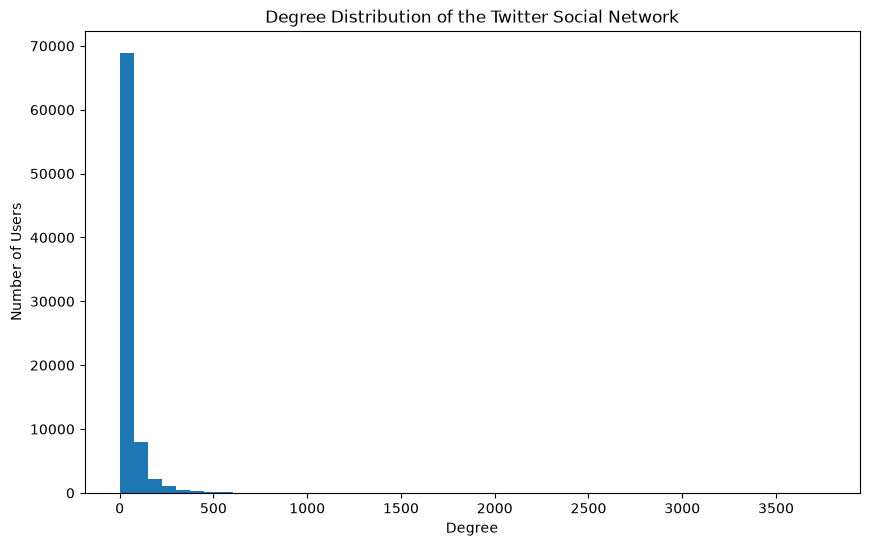

In [71]:
#visualization 1: degree distribution
import matplotlib.pyplot as plt

degree_values = [degree for node, degree in G.degree()]

plt.figure(figsize=(10, 6))

plt.hist(
    degree_values,
    bins=50
)

plt.xlabel("Degree")
plt.ylabel("Number of Users")
plt.title("Degree Distribution of the Twitter Social Network")

plt.show()

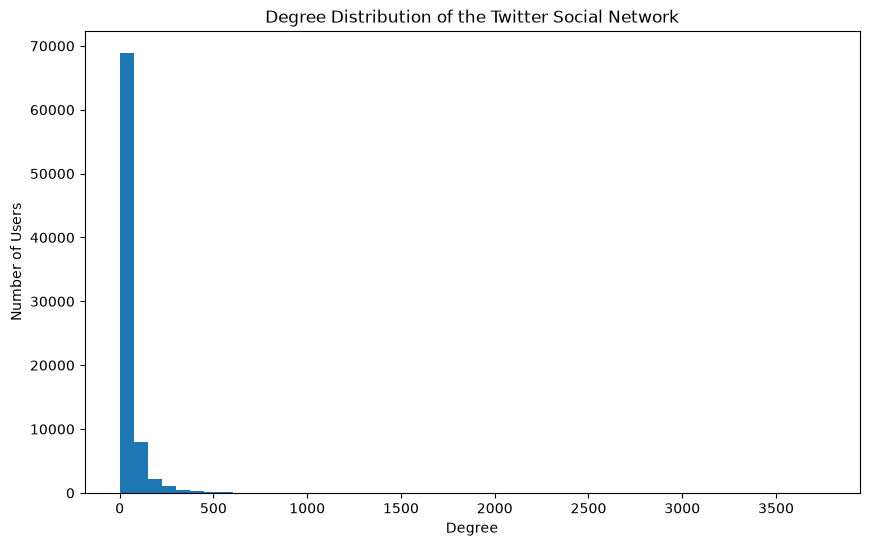

In [72]:
plt.figure(figsize=(10, 6))

plt.hist(degree_values, bins=50)

plt.xlabel("Degree")
plt.ylabel("Number of Users")
plt.title("Degree Distribution of the Twitter Social Network")

plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\degree_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

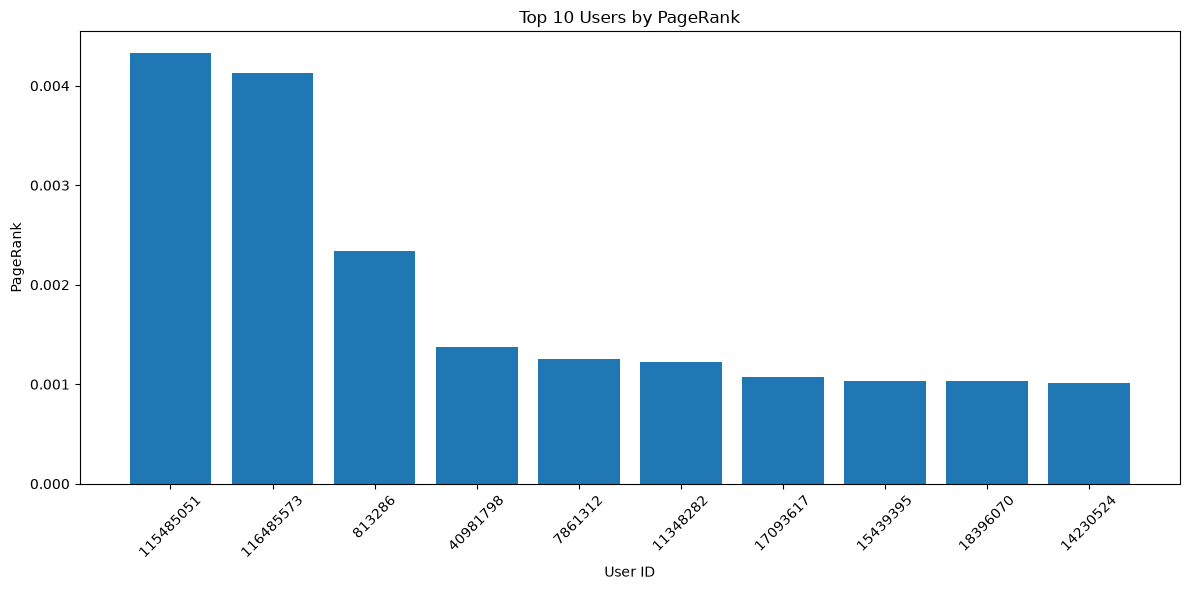

In [73]:
#visualization 2: top pagerank users
top10 = results.sort_values(
    "PageRank",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["user_id"].astype(str),
    top10["PageRank"]
)

plt.xlabel("User ID")
plt.ylabel("PageRank")
plt.title("Top 10 Users by PageRank")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_pagerank.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

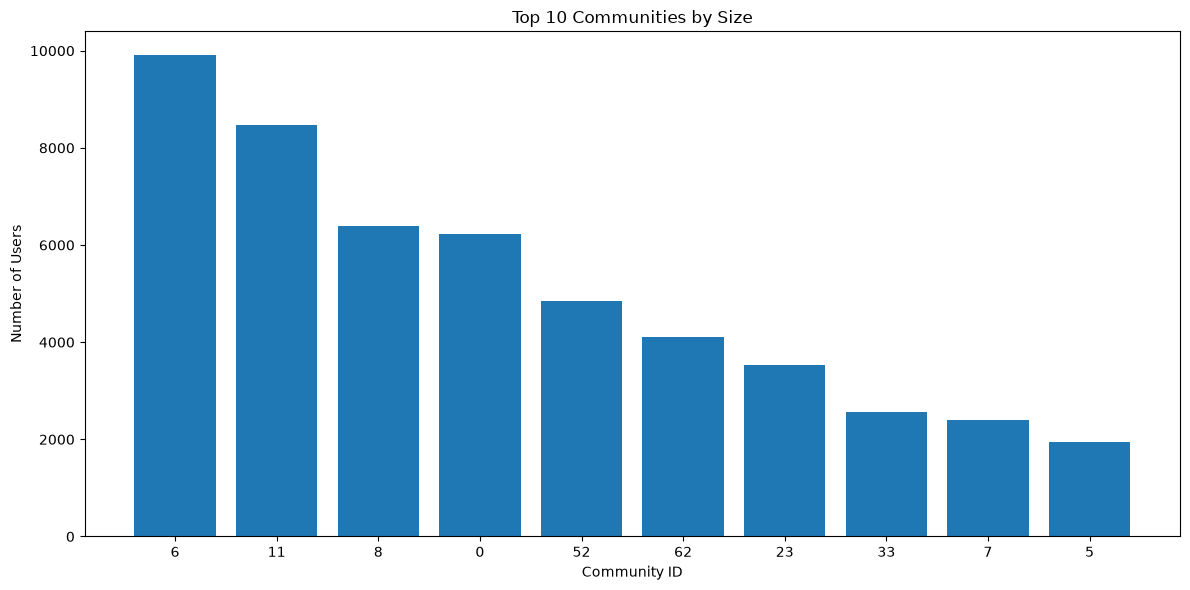

In [75]:
#visualization 3: community sizes
community_ids = [
    item[0] for item in top_communities
]

community_size_values = [
    item[1] for item in top_communities
]

plt.figure(figsize=(12, 6))

plt.bar(
    [str(x) for x in community_ids],
    community_size_values
)

plt.xlabel("Community ID")
plt.ylabel("Number of Users")
plt.title("Top 10 Communities by Size")

plt.tight_layout()
plt.show()

In [76]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\community_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [77]:
#NetworkX visualization
top_users = set(
    results.nlargest(100, "PageRank")["user_id"]
)

neighbor_nodes = set(top_users)

for user in top_users:
    neighbor_nodes.update(G.predecessors(user))
    neighbor_nodes.update(G.successors(user))

subgraph = G.subgraph(neighbor_nodes).copy()

print("Visualization network:")
print("Nodes:", subgraph.number_of_nodes())
print("Edges:", subgraph.number_of_edges())

Visualization network:
Nodes: 33821
Edges: 965857


In [80]:
#top 20 pagerank users
top_users = list(
    results.nlargest(20, "PageRank")["user_id"]
)

print("Selected users:", len(top_users))
print(top_users)

Selected users: 20
[115485051, 116485573, 813286, 40981798, 7861312, 11348282, 17093617, 15439395, 18396070, 14230524, 15485441, 90420314, 1183041, 16303106, 972651, 62581962, 43003845, 14824849, 428333, 30364057]


In [81]:
visual_graph = G.subgraph(top_users).copy()

print("Visualization nodes:", visual_graph.number_of_nodes())
print("Visualization edges:", visual_graph.number_of_edges())

Visualization nodes: 20
Visualization edges: 71


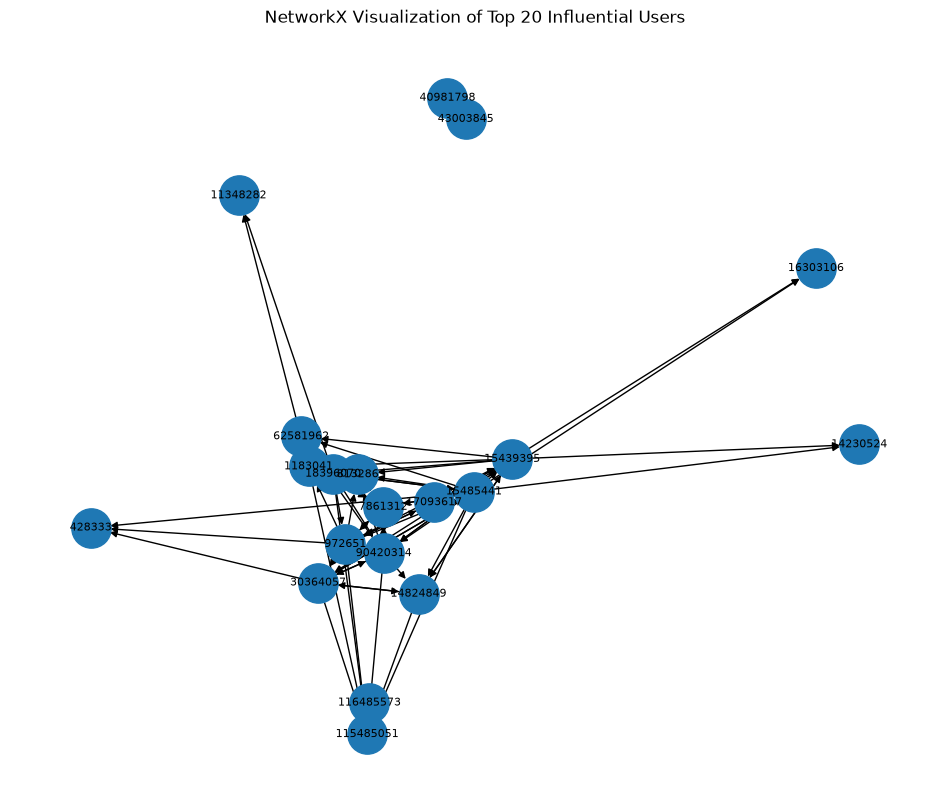

In [82]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    visual_graph,
    seed=42
)

nx.draw_networkx(
    visual_graph,
    pos,
    node_size=800,
    with_labels=True,
    font_size=8,
    arrows=True
)

plt.title("NetworkX Visualization of Top 20 Influential Users")
plt.axis("off")

plt.show()

In [83]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\networkx_top20_influential_users.png",
    dpi=300,
    bbox_inches="tight"
)

print("NetworkX visualization saved!")

NetworkX visualization saved!


<Figure size 640x480 with 0 Axes>

In [84]:
#export network to Gephi
gephi_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_social_network.gexf"

nx.write_gexf(G, gephi_path)

print("Network exported to Gephi successfully!")

Network exported to Gephi successfully!


In [85]:
#export community info

#create node attribute
nx.set_node_attributes(
    G,
    partition,
    "community"
)

#pagerank
nx.set_node_attributes(
    G,
    pagerank,
    "PageRank"
)

#betweenness
nx.set_node_attributes(
    G,
    betweenness,
    "betweenness"
)

#export again
nx.write_gexf(G, gephi_path)

print("Updated Gephi network exported!")

Updated Gephi network exported!


In [90]:
import os

gephi_folder = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi"

os.makedirs(gephi_folder, exist_ok=True)

gephi_path = os.path.join(
    gephi_folder,
    "twitter_social_network.gexf"
)

print("Export path:")
print(gephi_path)

Export path:
C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_social_network.gexf


In [91]:
print("Starting Gephi export...")
print("This may take several minutes for this large network.")
print("Please do not open the file while this is running.")

nx.write_gexf(G, gephi_path)

print("EXPORT FINISHED!")

Starting Gephi export...
This may take several minutes for this large network.
Please do not open the file while this is running.
EXPORT FINISHED!


In [92]:
file_size = os.path.getsize(gephi_path)

print("File size:", file_size, "bytes")
print("File size:", round(file_size / (1024 * 1024), 2), "MB")

File size: 133535566 bytes
File size: 127.35 MB


In [93]:
# Create a smaller network for Gephi visualization

top_users = sorted(
    pagerank,
    key=pagerank.get,
    reverse=True
)[:1000]

G_gephi = G.subgraph(top_users).copy()

print("Gephi visualization network created!")
print("Nodes:", G_gephi.number_of_nodes())
print("Edges:", G_gephi.number_of_edges())

Gephi visualization network created!
Nodes: 1000
Edges: 30628


In [94]:
# Export smaller network for Gephi

small_gephi_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_top1000.gexf"

nx.write_gexf(G_gephi, small_gephi_path)

print("Small Gephi network exported successfully!")
print("File:", small_gephi_path)

Small Gephi network exported successfully!
File: C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_top1000.gexf


## Community Detection

Community detection is used to identify groups of users that are more strongly connected to each other than to users outside the group. In this project, Louvain community detection is applied to the smaller network selected for Gephi visualization.

In [96]:
# Community detection using the Louvain algorithm

import networkx as nx

# Convert the visualization network to an undirected graph
G_community = G_gephi.to_undirected()

print("Running Louvain community detection...")
print("Nodes:", G_community.number_of_nodes())
print("Edges:", G_community.number_of_edges())

communities = nx.community.louvain_communities(
    G_community,
    seed=42
)

print("Community detection completed!")
print("Number of communities:", len(communities))

Running Louvain community detection...
Nodes: 1000
Edges: 23033
Community detection completed!
Number of communities: 18


In [97]:
# Display community sizes

community_sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

print("Community sizes:")
for i, size in enumerate(community_sizes, start=1):
    print(f"Community {i}: {size} users")

Community sizes:
Community 1: 269 users
Community 2: 260 users
Community 3: 178 users
Community 4: 163 users
Community 5: 90 users
Community 6: 21 users
Community 7: 3 users
Community 8: 2 users
Community 9: 2 users
Community 10: 2 users
Community 11: 2 users
Community 12: 2 users
Community 13: 1 users
Community 14: 1 users
Community 15: 1 users
Community 16: 1 users
Community 17: 1 users
Community 18: 1 users


In [100]:
# Assign community IDs to users

community_map = {}

for community_id, community in enumerate(communities, start=1):
    for user in community:
        community_map[user] = community_id

nx.set_node_attributes(
    G_gephi,
    community_map,
    "community"
)

print("Community labels assigned successfully!")

# Export the community-labelled network
small_gephi_path = r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_top1000_communities.gexf"

nx.write_gexf(G_gephi, small_gephi_path)

print("Community-labelled Gephi network exported successfully!")
print("File:", small_gephi_path)

Community labels assigned successfully!
Community-labelled Gephi network exported successfully!
File: C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\gephi\twitter_top1000_communities.gexf


## Final Results and Influential Users

The following table combines the major network measures used to identify influential, highly connected, and structurally important users in the social network.

In [101]:
# Final results table

final_top_users = results.sort_values(
    "PageRank",
    ascending=False
).head(20)

final_top_users[
    [
        "user_id",
        "in_degree",
        "out_degree",
        "PageRank",
        "betweenness",
        "community"
    ]
]

,user_id,in_degree,out_degree,PageRank,betweenness,community
1758,115485051,3383,1,0.004331,0.000010,6
8224,116485573,4,1,0.004133,0.000000,47
1550,813286,2647,1111,0.002339,0.165257,6
63,40981798,3216,119,0.001372,0.018777,0
436,7861312,2074,224,0.001254,0.014429,6
818,11348282,1707,172,0.001222,0.008104,23
2413,17093617,1186,687,0.001076,0.063684,33
501,15439395,1108,334,0.001031,0.030597,6
3506,18396070,265,45,0.001029,0.000521,6
3755,14230524,1214,62,0.001014,0.014207,0


In [102]:
final_top_users.to_csv(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\final_top_users.csv",
    index=False
)

print("Final ranking saved!")

Final ranking saved!


## Top Influential Users by PageRank

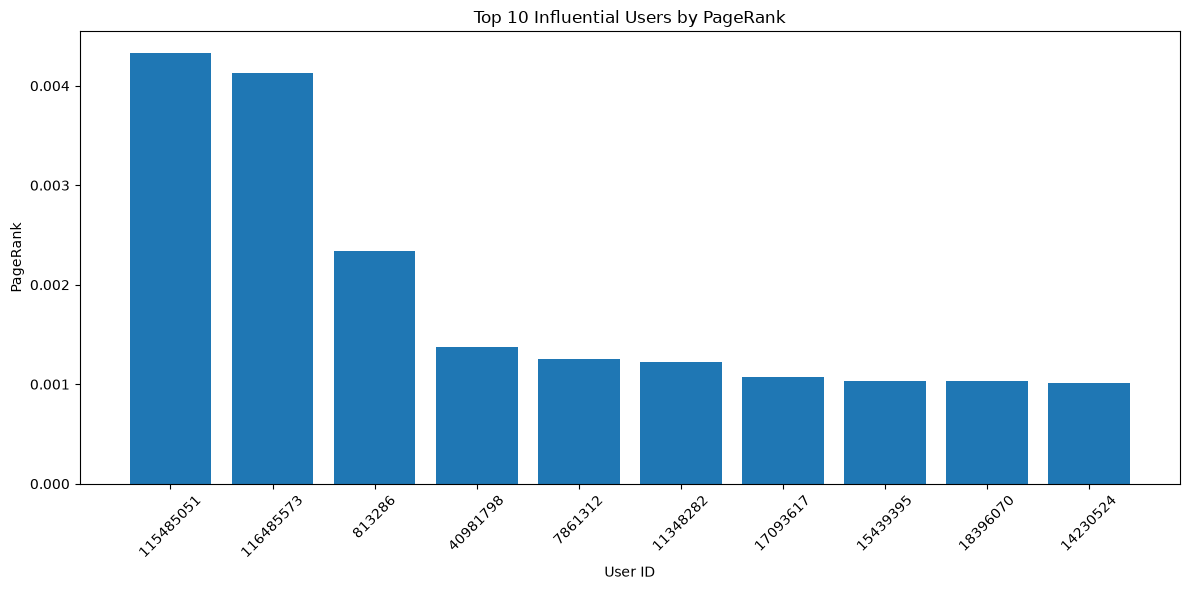

In [103]:
import matplotlib.pyplot as plt

top10 = results.sort_values(
    "PageRank",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["user_id"].astype(str),
    top10["PageRank"]
)

plt.xlabel("User ID")
plt.ylabel("PageRank")
plt.title("Top 10 Influential Users by PageRank")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [105]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_pagerank_users.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Top Bridge Users by Betweenness Centrality

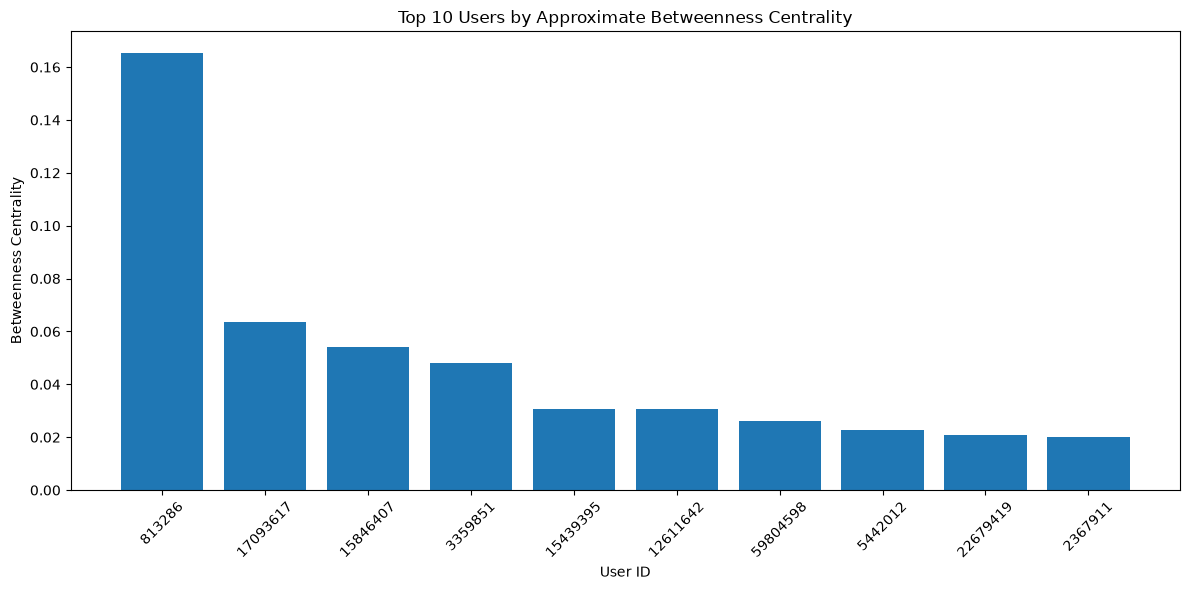

In [106]:
top10_betweenness = results.sort_values(
    "betweenness",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_betweenness["user_id"].astype(str),
    top10_betweenness["betweenness"]
)

plt.xlabel("User ID")
plt.ylabel("Betweenness Centrality")
plt.title("Top 10 Users by Approximate Betweenness Centrality")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [107]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\top_betweenness_users.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Degree Distribution

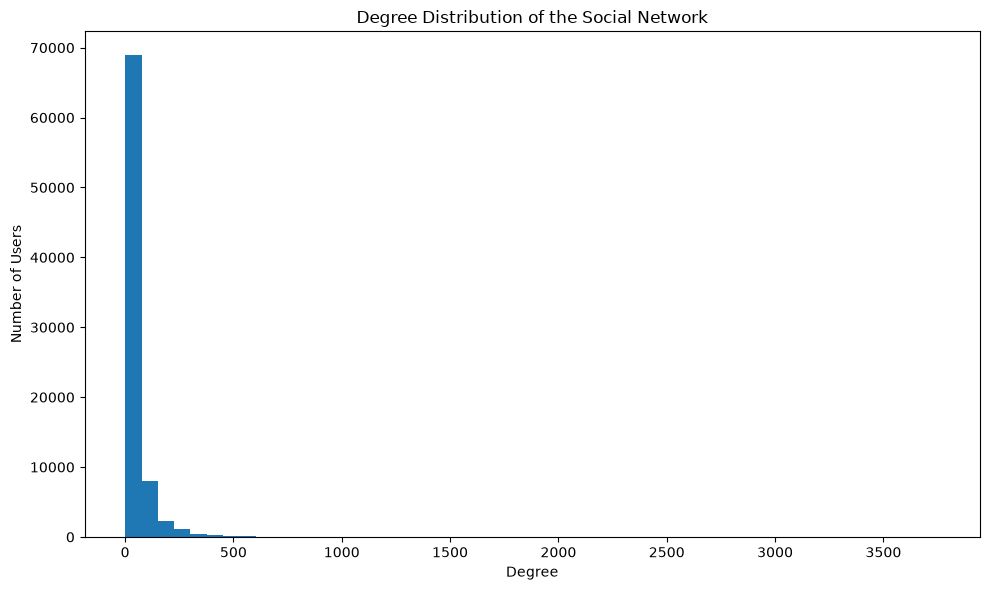

In [108]:
degree_values = [degree for node, degree in G.degree()]

plt.figure(figsize=(10, 6))

plt.hist(
    degree_values,
    bins=50
)

plt.xlabel("Degree")
plt.ylabel("Number of Users")
plt.title("Degree Distribution of the Social Network")

plt.tight_layout()
plt.show()

In [109]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\degree_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

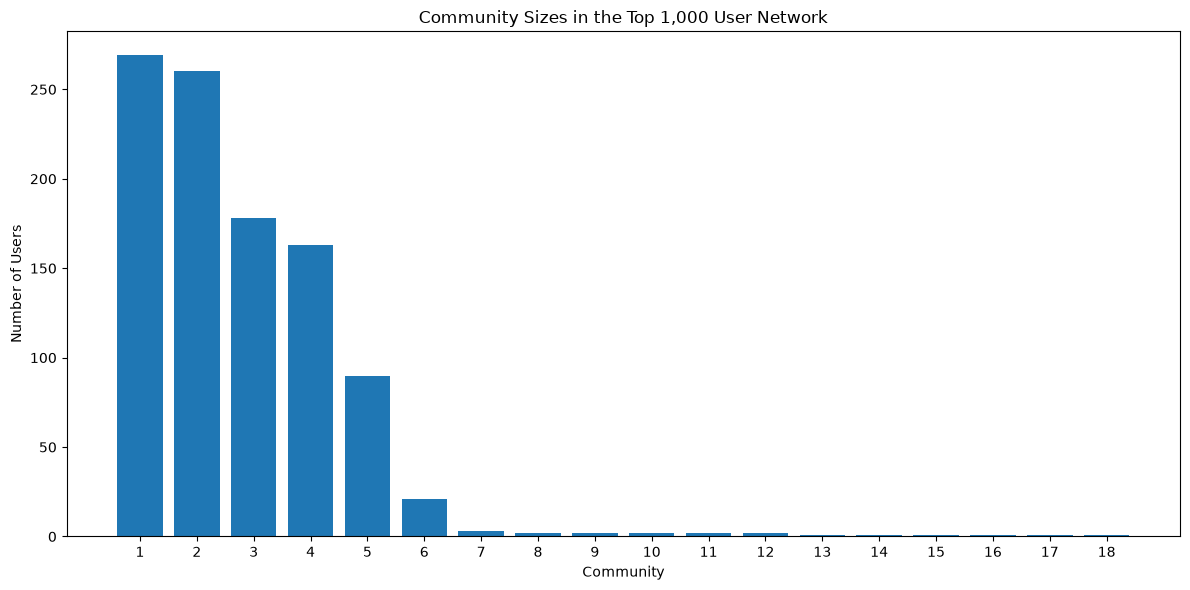

In [110]:
#community size chart
community_sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    range(1, len(community_sizes) + 1),
    community_sizes
)

plt.xlabel("Community")
plt.ylabel("Number of Users")
plt.title("Community Sizes in the Top 1,000 User Network")

plt.xticks(range(1, len(community_sizes) + 1))

plt.tight_layout()
plt.show()

In [111]:
plt.savefig(
    r"C:\Users\satap\OneDrive\Desktop\PROJECTS\SMA\outputs\community_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Network Summary

In [113]:
print("\nSOCIAL NETWORK SUMMARY")

print("Number of users:", G.number_of_nodes())
print("Number of directed connections:", G.number_of_edges())

print(
    "Network density:",
    nx.density(G)
)

print(
    "Connected components:",
    nx.number_connected_components(G_undirected)
)

print(
    "Average in-degree:",
    sum(dict(G.in_degree()).values()) / G.number_of_nodes()
)

print(
    "Average out-degree:",
    sum(dict(G.out_degree()).values()) / G.number_of_nodes()
)

print(
    "Number of communities in top-1000 visualization network:",
    len(communities)
)




SOCIAL NETWORK SUMMARY
Number of users: 81306
Number of directed connections: 1768135
Network density: 0.0002674703039451279
Connected components: 1
Average in-degree: 21.746673062258626
Average out-degree: 21.746673062258626
Number of communities in top-1000 visualization network: 18


In [114]:
#identify key users
print("=KEY USERS")

top_pagerank_user = results.loc[
    results["PageRank"].idxmax()
]

top_in_degree_user = results.loc[
    results["in_degree"].idxmax()
]

top_out_degree_user = results.loc[
    results["out_degree"].idxmax()
]

top_betweenness_user = results.loc[
    results["betweenness"].idxmax()
]

print(
    "Highest PageRank:",
    top_pagerank_user["user_id"]
)

print(
    "Highest in-degree:",
    top_in_degree_user["user_id"]
)

print(
    "Highest out-degree:",
    top_out_degree_user["user_id"]
)

print(
    "Highest betweenness:",
    top_betweenness_user["user_id"]
)

=KEY USERS
Highest PageRank: 115485051.0
Highest in-degree: 115485051.0
Highest out-degree: 59804598.0
Highest betweenness: 813286.0


## Key Network Insights

The analysis reveals that different centrality measures identify different types of important users. User 115485051 has the highest PageRank and in-degree, indicating a highly influential and widely connected position in the network. User 59804598 has the highest out-degree, indicating a high number of outgoing connections. User 813286 has the highest approximate betweenness centrality, suggesting that it occupies an important bridging position between different parts of the network.

### Network Density

The network density is approximately 0.000267. This very low density indicates that only a small fraction of all theoretically possible connections actually exist. Therefore, the Twitter network is highly sparse rather than fully interconnected.

### Network Connectivity

The undirected network contains one connected component consisting of all 81,306 users. This indicates that every user can be connected to every other user through at least one path when the direction of relationships is ignored.

### Community Structure

Louvain community detection identified 18 communities in the selected top-1,000-user network. These communities represent groups of users that have relatively stronger internal connectivity compared with their connections to other groups. Community structure provides insight into the organization and clustering of users within the social network.

### Strong and Weak Relationships

The selected Twitter dataset represents relationships as unweighted connections. Therefore, interaction frequency or relationship strength cannot be directly calculated from the available data. Instead, structural connectivity was examined using degree, PageRank, betweenness centrality, and community structure. This limitation is considered when interpreting strong and weak relationships.

## Conclusion

This project developed an end-to-end social media network analytics solution using a Twitter social network dataset. The workflow included data acquisition, preprocessing, network construction using NetworkX, network-level analysis, centrality analysis, community detection, and visualization using NetworkX and Gephi.

The network contained 81,306 users and 1,768,135 directed connections after preprocessing. The network density was approximately 0.000267, indicating a highly sparse network. When treated as an undirected network, all users belonged to a single connected component.

PageRank and degree-based measures identified highly influential and highly connected users, while approximate betweenness centrality identified users that occupy important bridging positions within the network. Louvain community detection identified 18 communities within the selected top-1,000-user visualization network.

NetworkX was used for computational network analysis and focused visualization, while Gephi was used to provide an interactive visualization of communities and influential users. Overall, the analysis demonstrates how social network analytics can be used to understand influence, connectivity, community structure, and the overall organization of a large social media network.